# 14. Feature families: the pre-registered test and its result

**Question.** Does adding any of the seven candidate feature families improve the models that serve? Task A is the segment-share model (serving logistic regression); Task B is the national share forecast (serving rule: same as last month).

**Answer in one line.** Two families (FA3 specialty momentum, FA2 activity history) pass the pre-registered rule, but they lower log-loss by only about 0.06%, so the serving models are left unchanged (DL-72). The outside data (FA5, FA6) and the national forecast do not improve.

**What this notebook is.** A reader of the stored result, not a re-run. The test was run by `modeling/feature_test.py` on the committed data under the rules fixed in [`feature_engineering_plan.md`](../docs/feature_engineering_plan.md) (DL-71) before any run, and repeated once with byte-identical output. Nothing here changes a threshold or a family. To re-run the test: `python -m oa_market_intelligence.modeling.feature_test --run` (a long run).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))
from oa_market_intelligence.modeling.feature_test import LOWER_A, SCENARIOS, TASK_A_FAMILIES

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
results = json.loads((ROOT / "data" / "reference" / "feature_test_results.json").read_text("utf-8"))
A, B = results["task_a"], results["task_b"]
print("seed", results["seed"], "| bootstrap draws", results["n_boot"])
print("Task A lower percentile:", round(A["lower_percentile"], 2), "| plan: 100 x 0.05 / 6 =", round(LOWER_A, 2))
print("Task B lower percentile:", B["lower_percentile"], "| plan: 2.5")

seed 0 | bootstrap draws 2000
Task A lower percentile: 0.83 | plan: 100 x 0.05 / 6 = 0.83
Task B lower percentile: 2.5 | plan: 2.5


## 1. The rules, fixed beforehand

| | Task A (segment share) | Task B (national share) |
|---|---|---|
| Reference | serving tuned logistic regression | "same as last month" (serves); plain ridge for effect size |
| Metric | binomial log-loss per visit | mean absolute error |
| Test months | 46 (walk-forward, 24-month minimum) | 48 |
| Resampling | whole months, 2,000 draws, seed 0 | moving blocks of 6 months |
| Pass | lower end of the paired improvement above 0 at the **0.83th** percentile (Bonferroni, 6 families) | same at the **2.5th** percentile (2 families) |
| Robust | also passes with COVID months (Mar to May 2020) removed **and** with the 2024 dip (Mar to Jul 2024) removed | passes with the dip months removed from scoring (COVID precedes the first test month) |

A family that passes the main run but not both extra runs is **fragile** and is not adopted. A combined model is allowed only if two or more families are robust, and is adopted only if it beats the best single one by the same rule.

## 2. Task A: the six families

In [2]:
rows = []
for scenario in SCENARIOS:
    block = A["scenarios"][scenario]
    for family, d in block["families"].items():
        rows.append({
            "scenario": scenario, "family": family, "improvement": d["estimate"],
            "lower": d["low"], "upper": d["high"], "months_better": d["months_better"],
            "n_months": block["n_test_months"], "passes": d["passes"],
            "reference_log_loss": block["reference_log_loss"],
        })
task_a = pd.DataFrame(rows)
task_a["relative_pct"] = 100 * task_a.improvement / task_a.reference_log_loss
verdicts = pd.Series(A["verdicts"], name="verdict")
main = task_a[task_a.scenario == "main"].set_index("family")
summary = main[["improvement", "lower", "upper", "relative_pct"]].copy()
summary["months_better"] = main.months_better.astype(str) + " / " + main.n_months.astype(str)
summary = summary.join(verdicts)
print("Reference log-loss, main run:", round(main.reference_log_loss.iloc[0], 5))
summary.round({"improvement": 7, "lower": 7, "upper": 7, "relative_pct": 3})

Reference log-loss, main run: 0.11274


,improvement,lower,upper,relative_pct,months_better,verdict
family,,,,,,
FA1,-0.000002,-0.000009,0.000005,-0.002,21 / 46,no_pass
FA2,0.000061,0.000010,0.000113,0.054,31 / 46,robust
FA3,0.000065,0.000044,0.000090,0.058,42 / 46,robust
FA4,0.000030,0.000011,0.000051,0.027,33 / 46,fragile
FA5,-0.000023,-0.000105,0.000052,-0.020,21 / 46,no_pass
FA6,0.000005,-0.000036,0.000038,0.004,22 / 46,no_pass


Positive is better. *lower* is the lower end at the 0.83th percentile, the number the rule looks at. *relative_pct* is the improvement as a share of the reference log-loss.

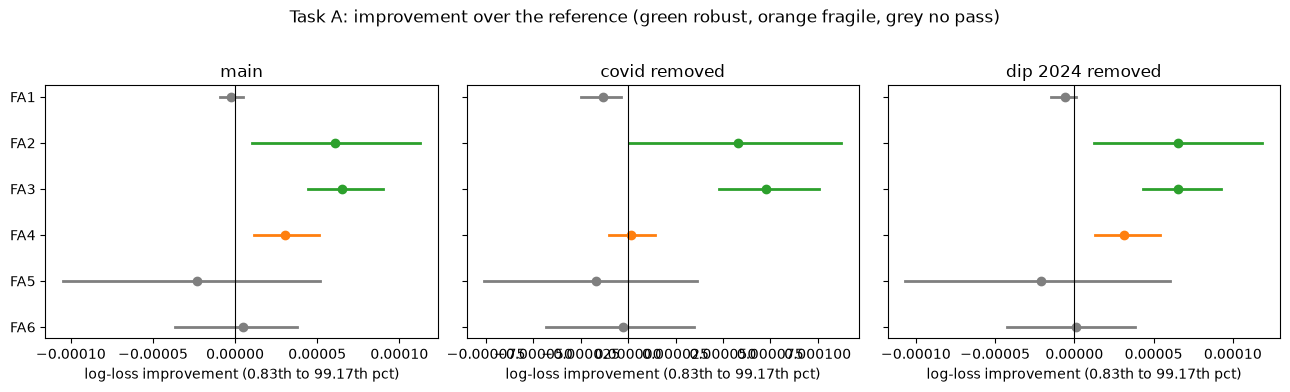

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
colors = {"robust": "#2ca02c", "fragile": "#ff7f0e", "no_pass": "#7f7f7f"}
families = list(TASK_A_FAMILIES)[::-1]
for ax, scenario in zip(axes, SCENARIOS):
    part = task_a[task_a.scenario == scenario].set_index("family").loc[families]
    for y, (family, r) in enumerate(part.iterrows()):
        color = colors[A["verdicts"][family]]
        ax.plot([r.lower, r.upper], [y, y], color=color, lw=2)
        ax.plot(r.improvement, y, "o", color=color)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(range(len(families)), families)
    ax.set_title(scenario.replace("_", " "))
    ax.set_xlabel("log-loss improvement (0.83th to 99.17th pct)")
fig.suptitle(
    "Task A: improvement over the reference (green robust, orange fragile, grey no pass)", y=1.02
)
plt.tight_layout()
plt.show()

The three runs side by side (lower end of each interval, and whether the family passed):

In [4]:
order = list(SCENARIOS)
lower = task_a.pivot(index="family", columns="scenario", values="lower")[order].add_prefix("lower, ")
passed = task_a.pivot(index="family", columns="scenario", values="passes")[order].add_prefix("passes, ")
lower.join(passed).join(verdicts).round(7)

,"lower, main","lower, covid_removed","lower, dip_2024_removed","passes, main","passes, covid_removed","passes, dip_2024_removed",verdict
family,,,,,,,
FA1,-0.000009,-2.500000e-05,-0.000015,False,False,False,no_pass
FA2,0.000010,6.000000e-07,0.000013,True,True,True,robust
FA3,0.000044,4.820000e-05,0.000043,True,True,True,robust
FA4,0.000011,-1.040000e-05,0.000013,True,False,True,fragile
FA5,-0.000105,-7.590000e-05,-0.000107,False,False,False,no_pass
FA6,-0.000036,-4.310000e-05,-0.000042,False,False,False,no_pass


## 3. How big is "robust"?

The rule asks whether the improvement is reliably above zero, not whether it is large. For the two robust families, here is the size against the reference model's log-loss per visit.

In [5]:
for family in ("FA3", "FA2"):
    d = main.loc[family]
    print(
        f"{family}: {d.improvement:.2e} on {d.reference_log_loss:.4f} = {d.relative_pct:.3f}% "
        f"of log-loss; better in {int(d.months_better)} of {int(d.n_months)} test months"
    )
c = A["combined"]
print(
    f"Combined {' + '.join(c['families'])} against {c['best_single']}: "
    f"{c['estimate']:.2e} (lower end {c['low']:.2e}); adopted = {c['adopted']}"
)

FA3: 6.50e-05 on 0.1127 = 0.058% of log-loss; better in 42 of 46 test months
FA2: 6.09e-05 on 0.1127 = 0.054% of log-loss; better in 31 of 46 test months
Combined FA2 + FA3 against FA3: 2.65e-05 (lower end -6.20e-06); adopted = False


FA3 is better in most months, so the direction is consistent, but the amount is a fraction of a tenth of a percent. The combination does not beat FA3 alone (its lower end is below zero), so it is not adopted.

## 4. Task B: the national forecast

In [6]:
rows = []
for scenario, block in B["scenarios"].items():
    for family, d in block["families"].items():
        rows.append({
            "scenario": scenario, "family": family, "n_months": block["n_test_months"],
            "vs last month": d["against_last_month"]["estimate"],
            "lower (vs last month)": d["against_last_month"]["low"],
            "vs plain ridge": d["against_plain_ridge"]["estimate"],
            "passes": d["passes"],
        })
task_b = pd.DataFrame(rows)
mae = {k: round(v, 4) for k, v in B["scenarios"]["main"]["mae"].items()}
print("Main-run mean absolute error (points of share):", mae)
print("Verdicts:", B["verdicts"])
task_b.round(4)

Main-run mean absolute error (points of share): {'last_month': 0.1246, 'ridge': 0.1466, 'ridge+FB1': 0.1525, 'ridge+FA5': 0.1639}
Verdicts: {'FB1': 'no_pass', 'FA5': 'no_pass'}


,scenario,family,n_months,vs last month,lower (vs last month),vs plain ridge,passes
0,main,FB1,48,-0.0279,-0.0660,-0.0059,False
1,main,FA5,48,-0.0393,-0.0813,-0.0173,False
2,dip_2024_removed,FB1,43,-0.0250,-0.0637,-0.0032,False
3,dip_2024_removed,FA5,43,-0.0219,-0.0440,0.0000,False


Positive means the family lowered the error. Both candidates are worse than "same as last month" and no better than the plain ridge, in the main run and with the 2024 dip removed. The national forecast stays on the rule that serves.

## 5. What we conclude

1. **Two families pass the rule; the gain is negligible.** FA3 (the specialty's recent share and its change) and FA2 (how long the segment has been active) are robust, at about 0.06% of log-loss. The plan expected up to a few percent. The serving logistic regression is left unchanged (decision recorded in DL-72): a new feature for no visible gain adds code to maintain and nothing to the story.
2. **The outside data adds nothing at monthly level.** FA5 (price ratio, company sales growth, months since an event) and FA6 (Medicare adoption) do not pass in any run. This agrees with the availability work: most public series arrive too late or too coarse to inform a month.
3. **The national forecast does not improve.** Both candidates are worse than last month.
4. **FA4 is fragile.** The EDA-informed seasonal gap holds in the main run and without the 2024 dip, and fails without the COVID months.

## Limits stated in the plan

- FA4 and FB1 were chosen after the EDA: they are labelled *not a clean test*.
- The combined-model test is conditional and does not exactly control the family-wise error rate.
- Task B has no COVID scenario (the COVID months fall before the first test month): an implementation choice.
- The rule is a significance rule with no minimum effect size, so "passes" is not "worth using".

A near-null result is a finding. The segment-level models are limited by the thin panel (most segment-months are under 20 visits) and the national series by its few independent months, not by a missing feature.